In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

RAW = '../data/raw/'
PROCESSED = '../data/processed/'
FINAL = '../data/final/'
FIGURES = '../outputs/figures/'

# Cargar dataset final
df = pd.read_csv(FINAL + 'dataset_barrios.csv')

print(f'Dataset cargado: {df.shape}')

Dataset cargado: (131, 20)


In [3]:
#Estadísticas descriptivas

#Seleccionamos solo las variables analíticas
variables = [
    'pct_extranjera', 'pct_65mas', 'pct_pob_2044', 'pct_extranjera_2044',
    'var_extranjera_1823', 'var_65mas_1823', 'var_pob_2044_1823', 'var_extranjera_2044_1823',
    'pct_hosteleria_2023', 'pct_servicios_prof', 'pct_comercio_tradicional', 'pct_inmobiliario',
    'var_hosteleria_1823', 'alquiler_2023', 'var_alquiler_dist_1823', 'catastral_m2', 'var_catastral_m2_2023']

#Estadísticas descriptivas
stats = df[variables].describe().round(2)
print('Estadísticas descriptivas')
print(stats.to_string())

stats.to_csv('../outputs/tables/estadisticas_descriptivas.csv')

Estadísticas descriptivas
       pct_extranjera  pct_65mas  pct_pob_2044  pct_extranjera_2044  var_extranjera_1823  var_65mas_1823  var_pob_2044_1823  var_extranjera_2044_1823  pct_hosteleria_2023  pct_servicios_prof  pct_comercio_tradicional  pct_inmobiliario  var_hosteleria_1823  alquiler_2023  var_alquiler_dist_1823  catastral_m2  var_catastral_m2_2023
count          131.00     131.00        131.00               131.00               131.00          131.00             131.00                    131.00               131.00              131.00                    131.00            131.00               131.00         131.00                  131.00        131.00                 131.00
mean            16.32      20.09         33.48                 9.43                 3.73            0.18              -0.41                      2.01                22.34                4.25                     49.31              1.25                 0.51          15.13                   17.16       1107.90  

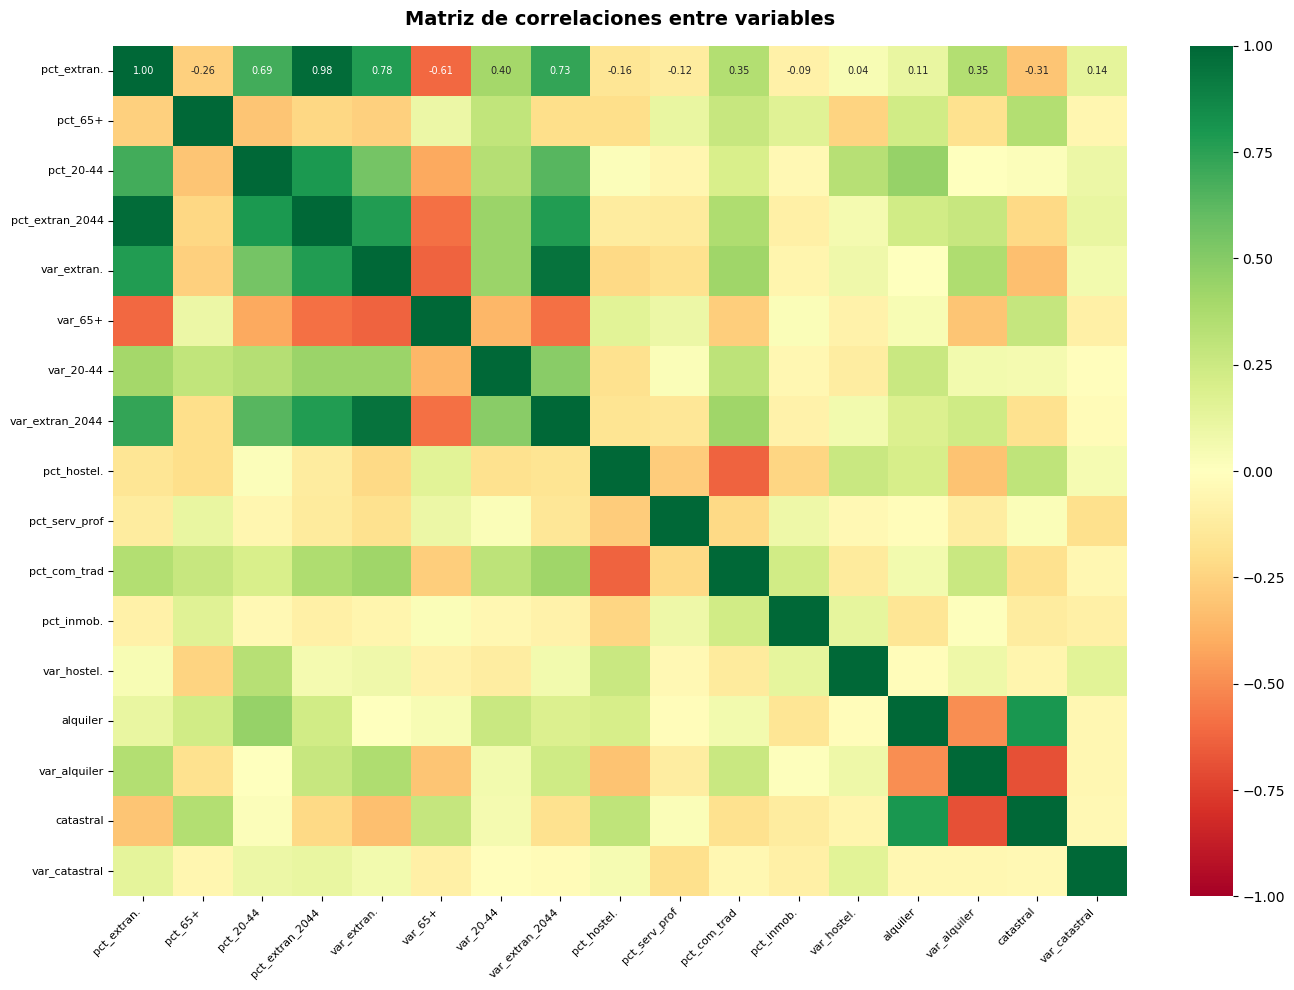

In [4]:
#Matriz de correlaciones

fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df[variables].corr().round(2)
etiquetas = [
    'pct_extran.', 'pct_65+', 'pct_20-44', 'pct_extran_2044',
    'var_extran.', 'var_65+', 'var_20-44', 'var_extran_2044',
    'pct_hostel.', 'pct_serv_prof', 'pct_com_trad', 'pct_inmob.',
    'var_hostel.', 'alquiler', 'var_alquiler', 'catastral', 'var_catastral']

#Mapa de calor
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    xticklabels=etiquetas,
    yticklabels=etiquetas,
    ax=ax,
    annot_kws={'size': 7})

ax.set_title('Matriz de correlaciones entre variables', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()

plt.savefig(FIGURES + 'correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
#Top 10 barrios por variable

variables_clave = {
    'alquiler_2023': 'Precio alquiler €/m² (2023)',
    'catastral_m2': 'Valor catastral €/m² (2023)',
    'pct_extranjera': '% Población extranjera (2023)',
    'pct_extranjera_2044': '% Población extranjera 20-44 años (2023)',
    'pct_hosteleria_2023': '% Locales hostelería y ocio (2023)',
    'var_hosteleria_1823': 'Variación hostelería 2018-2023 (pp)',
    'var_alquiler_dist_1823': 'Variación alquiler distrito 2018-2023 (%)',
    'pct_65mas': '% Población mayor 65 años (2023)'}

for variable, titulo in variables_clave.items():
    print(f'\n TOP 10 - {titulo}')
    print('-' * 55)
    top10 = df[['barrio', variable]].sort_values(
        variable, ascending=False
    ).head(10)
    for _, row in top10.iterrows():
        print(f"  {row['barrio']:<35} {row[variable]:>8.2f}")


 TOP 10 - Precio alquiler €/m² (2023)
-------------------------------------------------------
  041. Recoletos                         24.20
  014. Justicia                          22.60
  046. Castellana                        22.38
  073. Trafalgar                         22.09
  074. Almagro                           21.92
  042. Goya                              21.20
  045. Lista                             21.10
  015. Universidad                       21.07
  016. Sol                               20.49
  013. Cortes                            20.39

 TOP 10 - Valor catastral €/m² (2023)
-------------------------------------------------------
  035. Los Jerónimos                   2185.70
  041. Recoletos                       2056.80
  051. El Viso                         2045.95
  046. Castellana                      2012.75
  092. Argüelles                       1882.39
  036. Niño Jesús                      1741.10
  055. Nueva España                    1703.74
  034. Ibiz

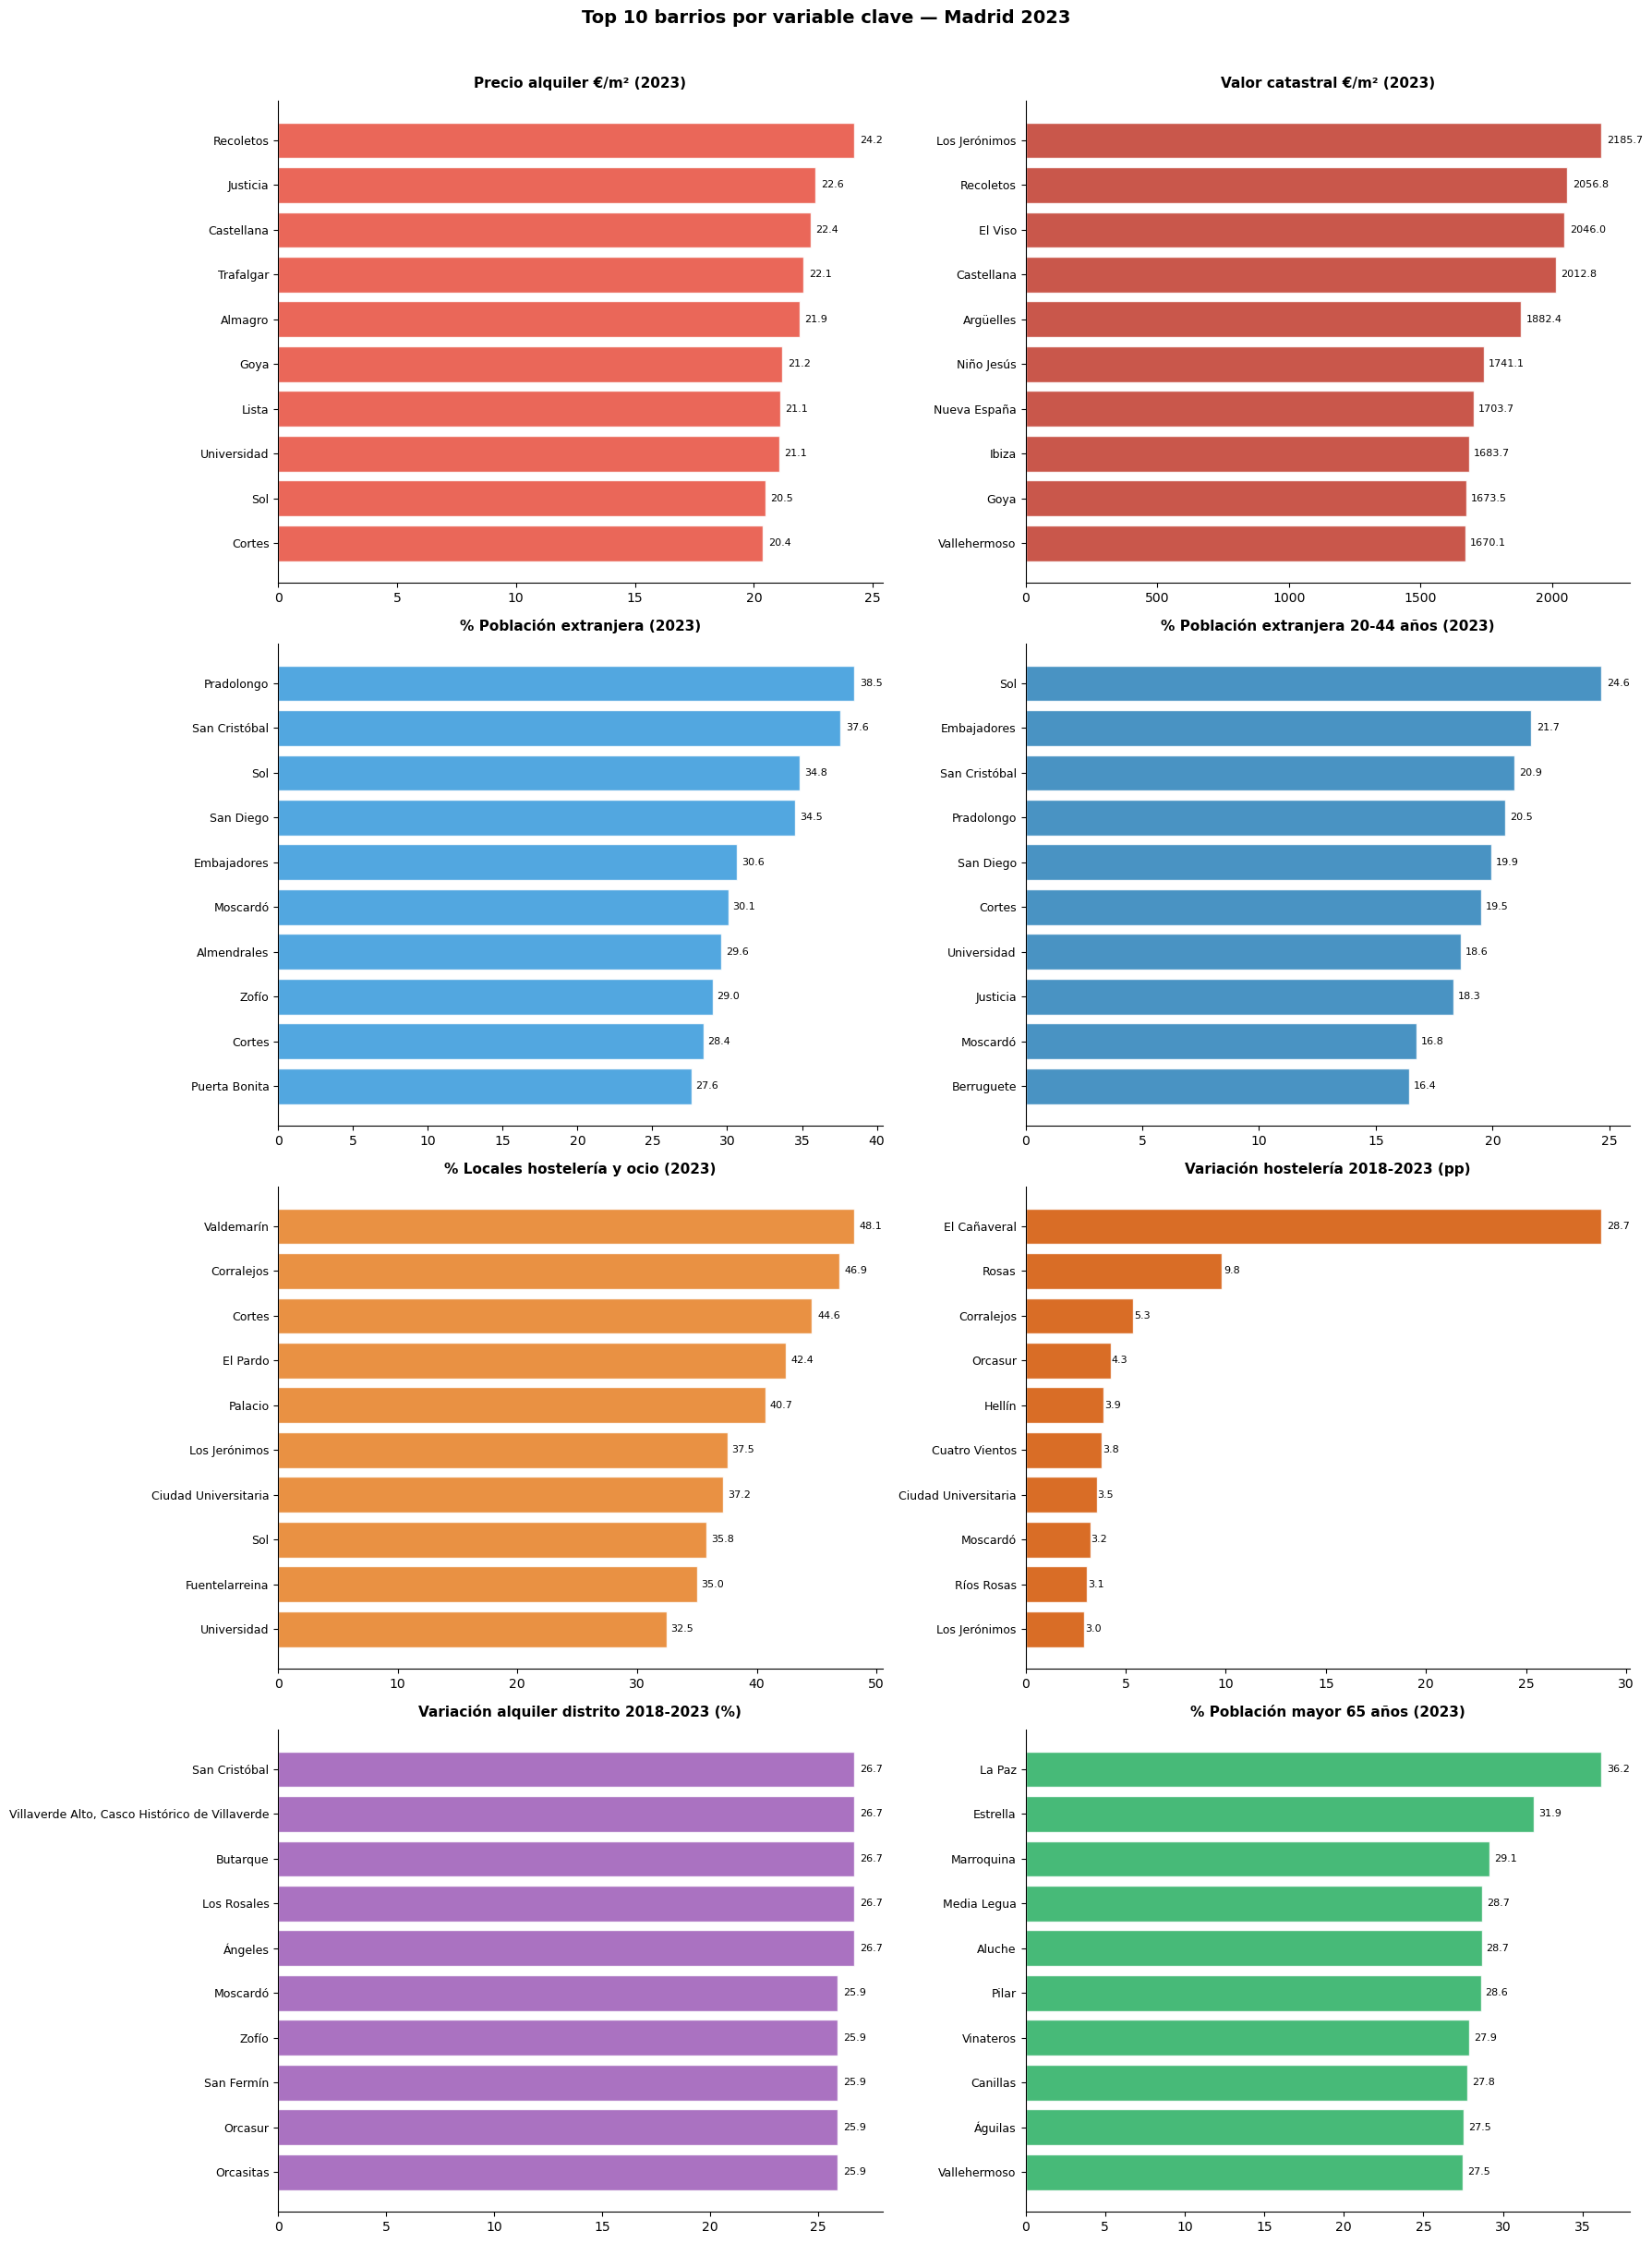

In [6]:
#Gráfico top 10 por variable

fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

colores = {
    'alquiler_2023': '#E74C3C',
    'catastral_m2': '#C0392B',
    'pct_extranjera': '#3498DB',
    'pct_extranjera_2044': '#2980B9',
    'pct_hosteleria_2023': '#E67E22',
    'var_hosteleria_1823': '#D35400',
    'var_alquiler_dist_1823': '#9B59B6',
    'pct_65mas': '#27AE60'}

for i, (variable, titulo) in enumerate(variables_clave.items()):
    top10 = df[['barrio', variable]].sort_values(
        variable, ascending=True).tail(10)
    
    #Limpiamos nombres de barrio
    top10['nombre'] = top10['barrio'].apply(
        lambda x: x.split('. ', 1)[1] if '. ' in x else x)
    
    axes[i].barh(
        top10['nombre'], 
        top10[variable],
        color=colores[variable],
        alpha=0.85,
        edgecolor='white')
    
    axes[i].set_title(titulo, fontsize=11, fontweight='bold', pad=10)
    axes[i].set_xlabel('')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].tick_params(axis='y', labelsize=9)
    
    #Añadimos valores al final de cada barra
    for j, (_, row) in enumerate(top10.iterrows()):
        axes[i].text(
            row[variable] * 1.01, j, 
            f'{row[variable]:.1f}', 
            va='center', fontsize=8)

plt.suptitle('Top 10 barrios por variable clave — Madrid 2023', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES + 'top10_variables.png', dpi=150, bbox_inches='tight')
plt.show()

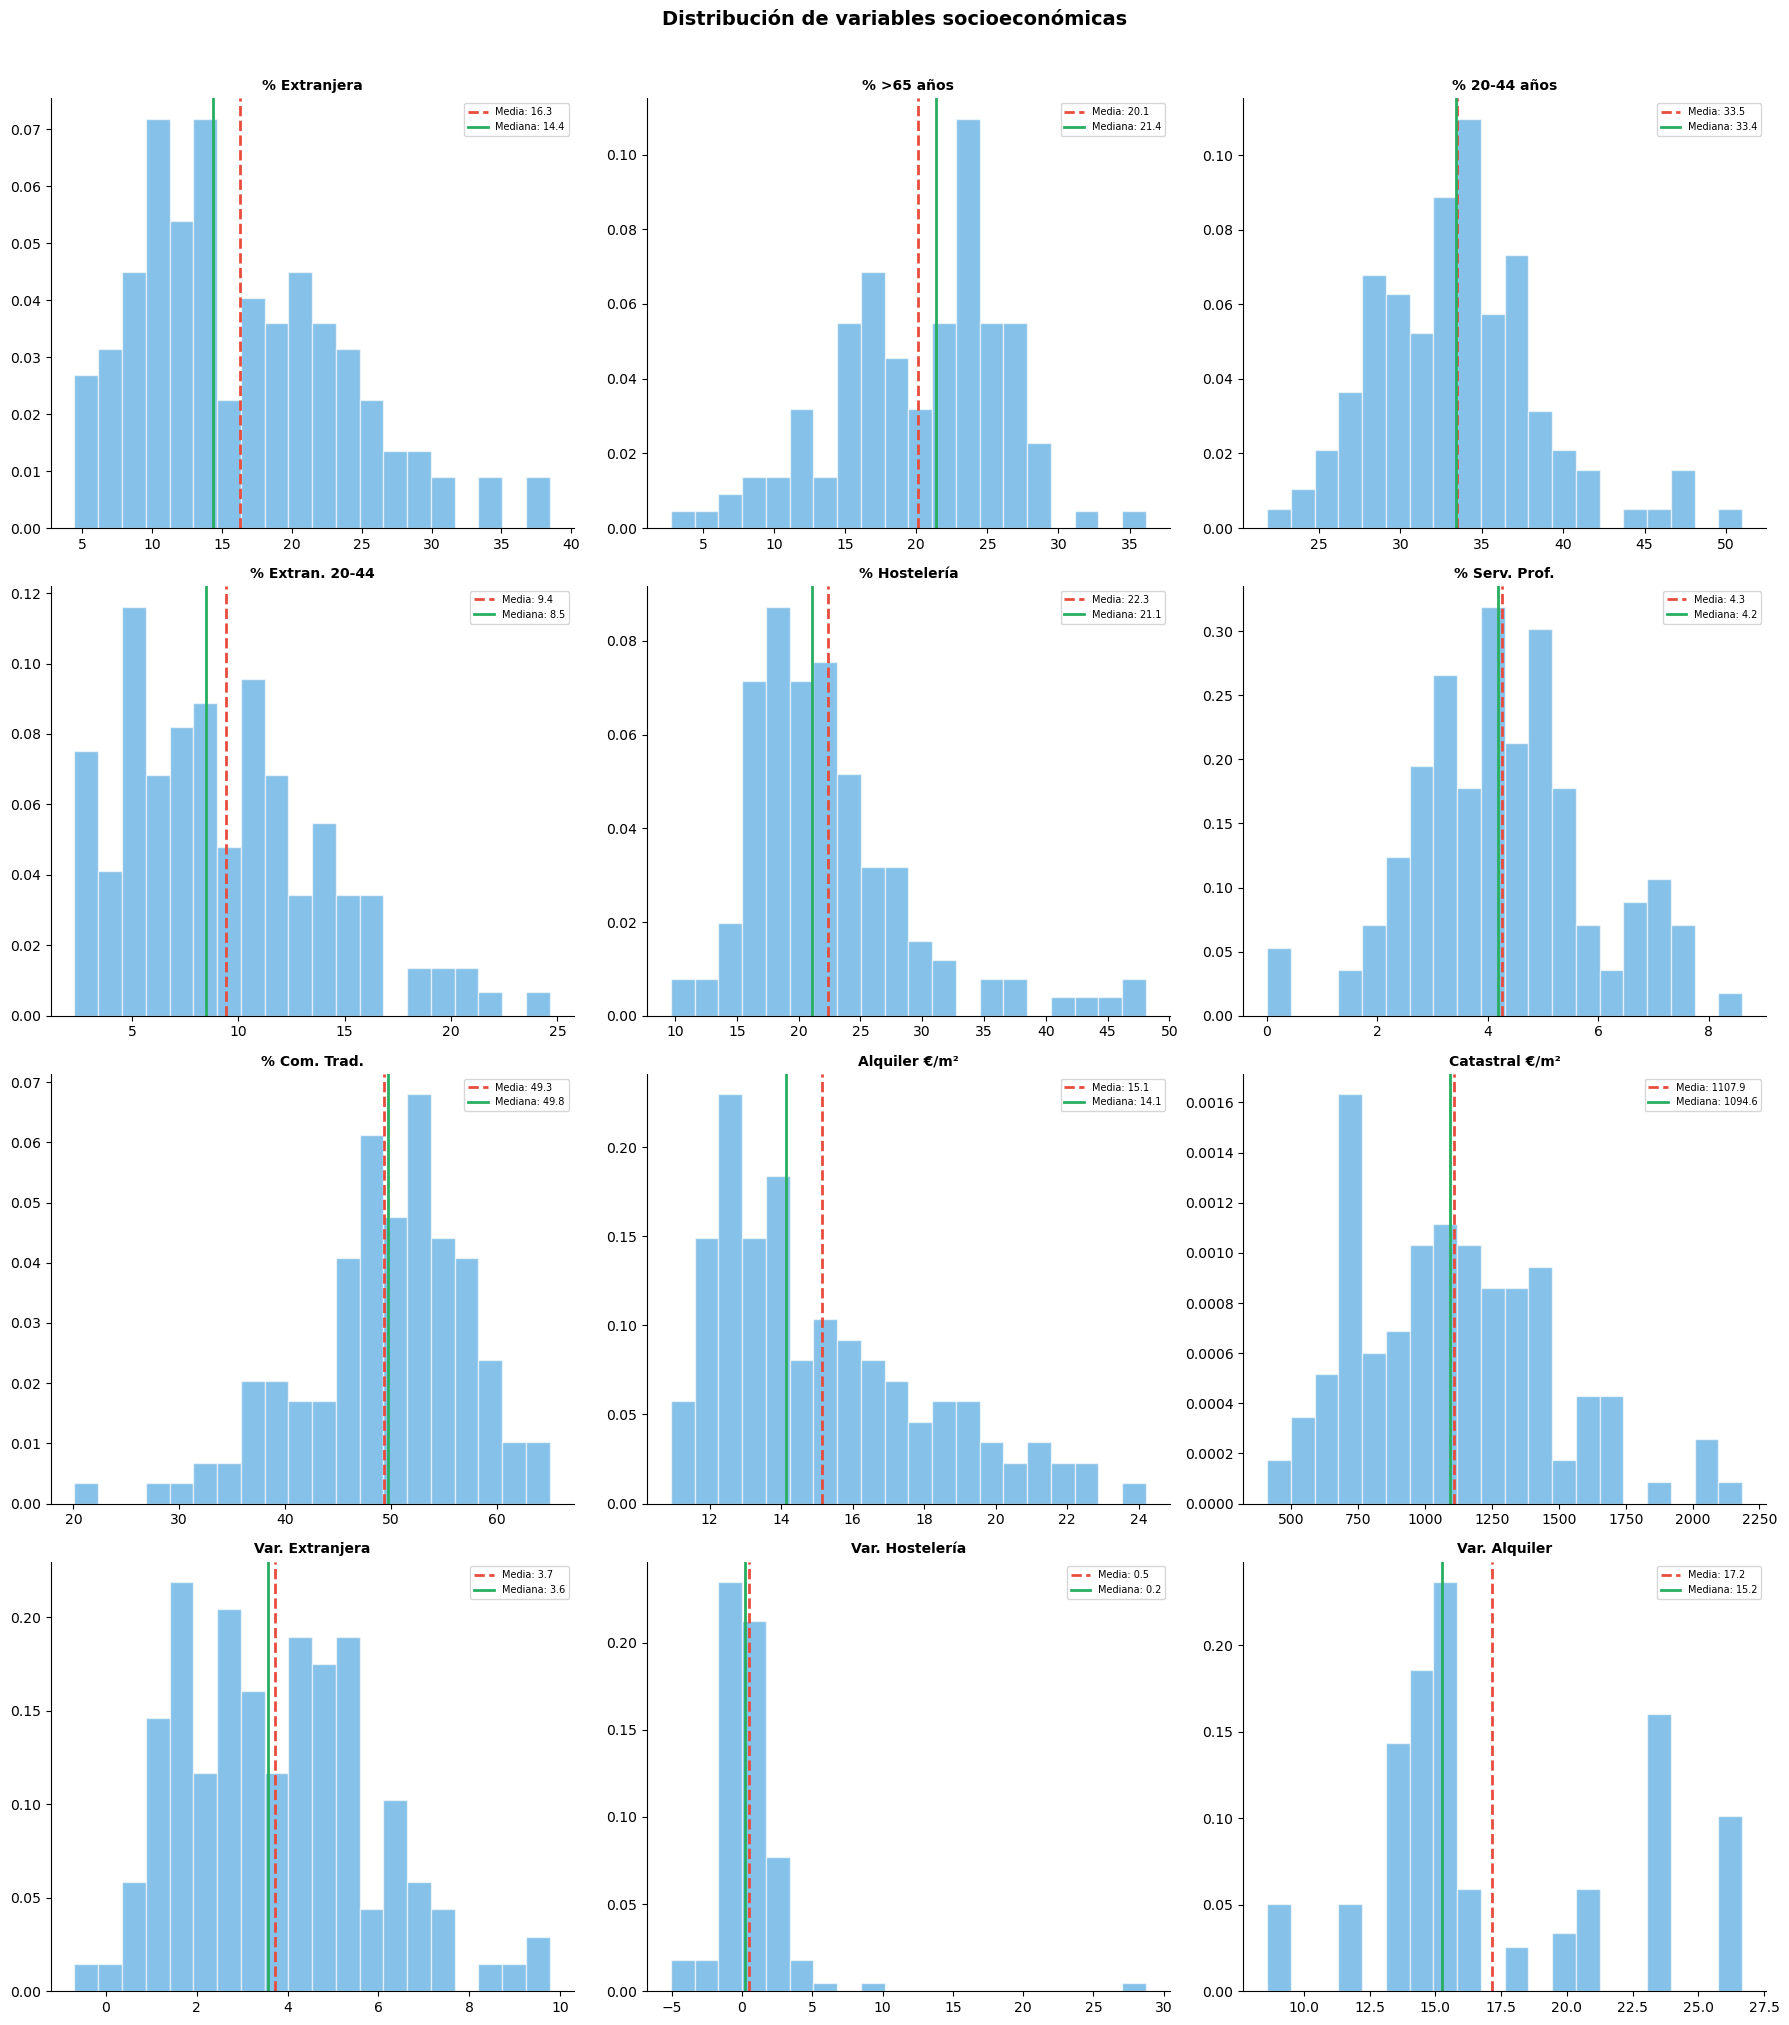

In [10]:
#Boxplot y histograma

variables_plot = [
    'pct_extranjera', 'pct_65mas', 'pct_pob_2044', 'pct_extranjera_2044',
    'pct_hosteleria_2023', 'pct_servicios_prof', 'pct_comercio_tradicional',
    'alquiler_2023', 'catastral_m2',
    'var_extranjera_1823', 'var_hosteleria_1823', 'var_alquiler_dist_1823']

etiquetas = [
    '% Extranjera', '% >65 años', '% 20-44 años', '% Extran. 20-44',
    '% Hostelería', '% Serv. Prof.', '% Com. Trad.',
    'Alquiler €/m²', 'Catastral €/m²',
    'Var. Extranjera', 'Var. Hostelería', 'Var. Alquiler']

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, (var, etiqueta) in enumerate(zip(variables_plot, etiquetas)):
    ax = axes[i]
    
    #Histograma con curva KDE
    datos = df[var].dropna()
    ax.hist(datos, bins=20, color='#3498DB', alpha=0.6, edgecolor='white', density=True)
    
    #Media y mediana
    ax.axvline(datos.mean(), color='#E74C3C', linewidth=2, linestyle='--', label=f'Media: {datos.mean():.1f}')
    ax.axvline(datos.median(), color='#27AE60', linewidth=2, linestyle='-', label=f'Mediana: {datos.median():.1f}')
    ax.set_title(etiqueta, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Distribución de variables socioeconómicas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES + 'histogramas_variables.png', dpi=150, bbox_inches='tight')
plt.show()

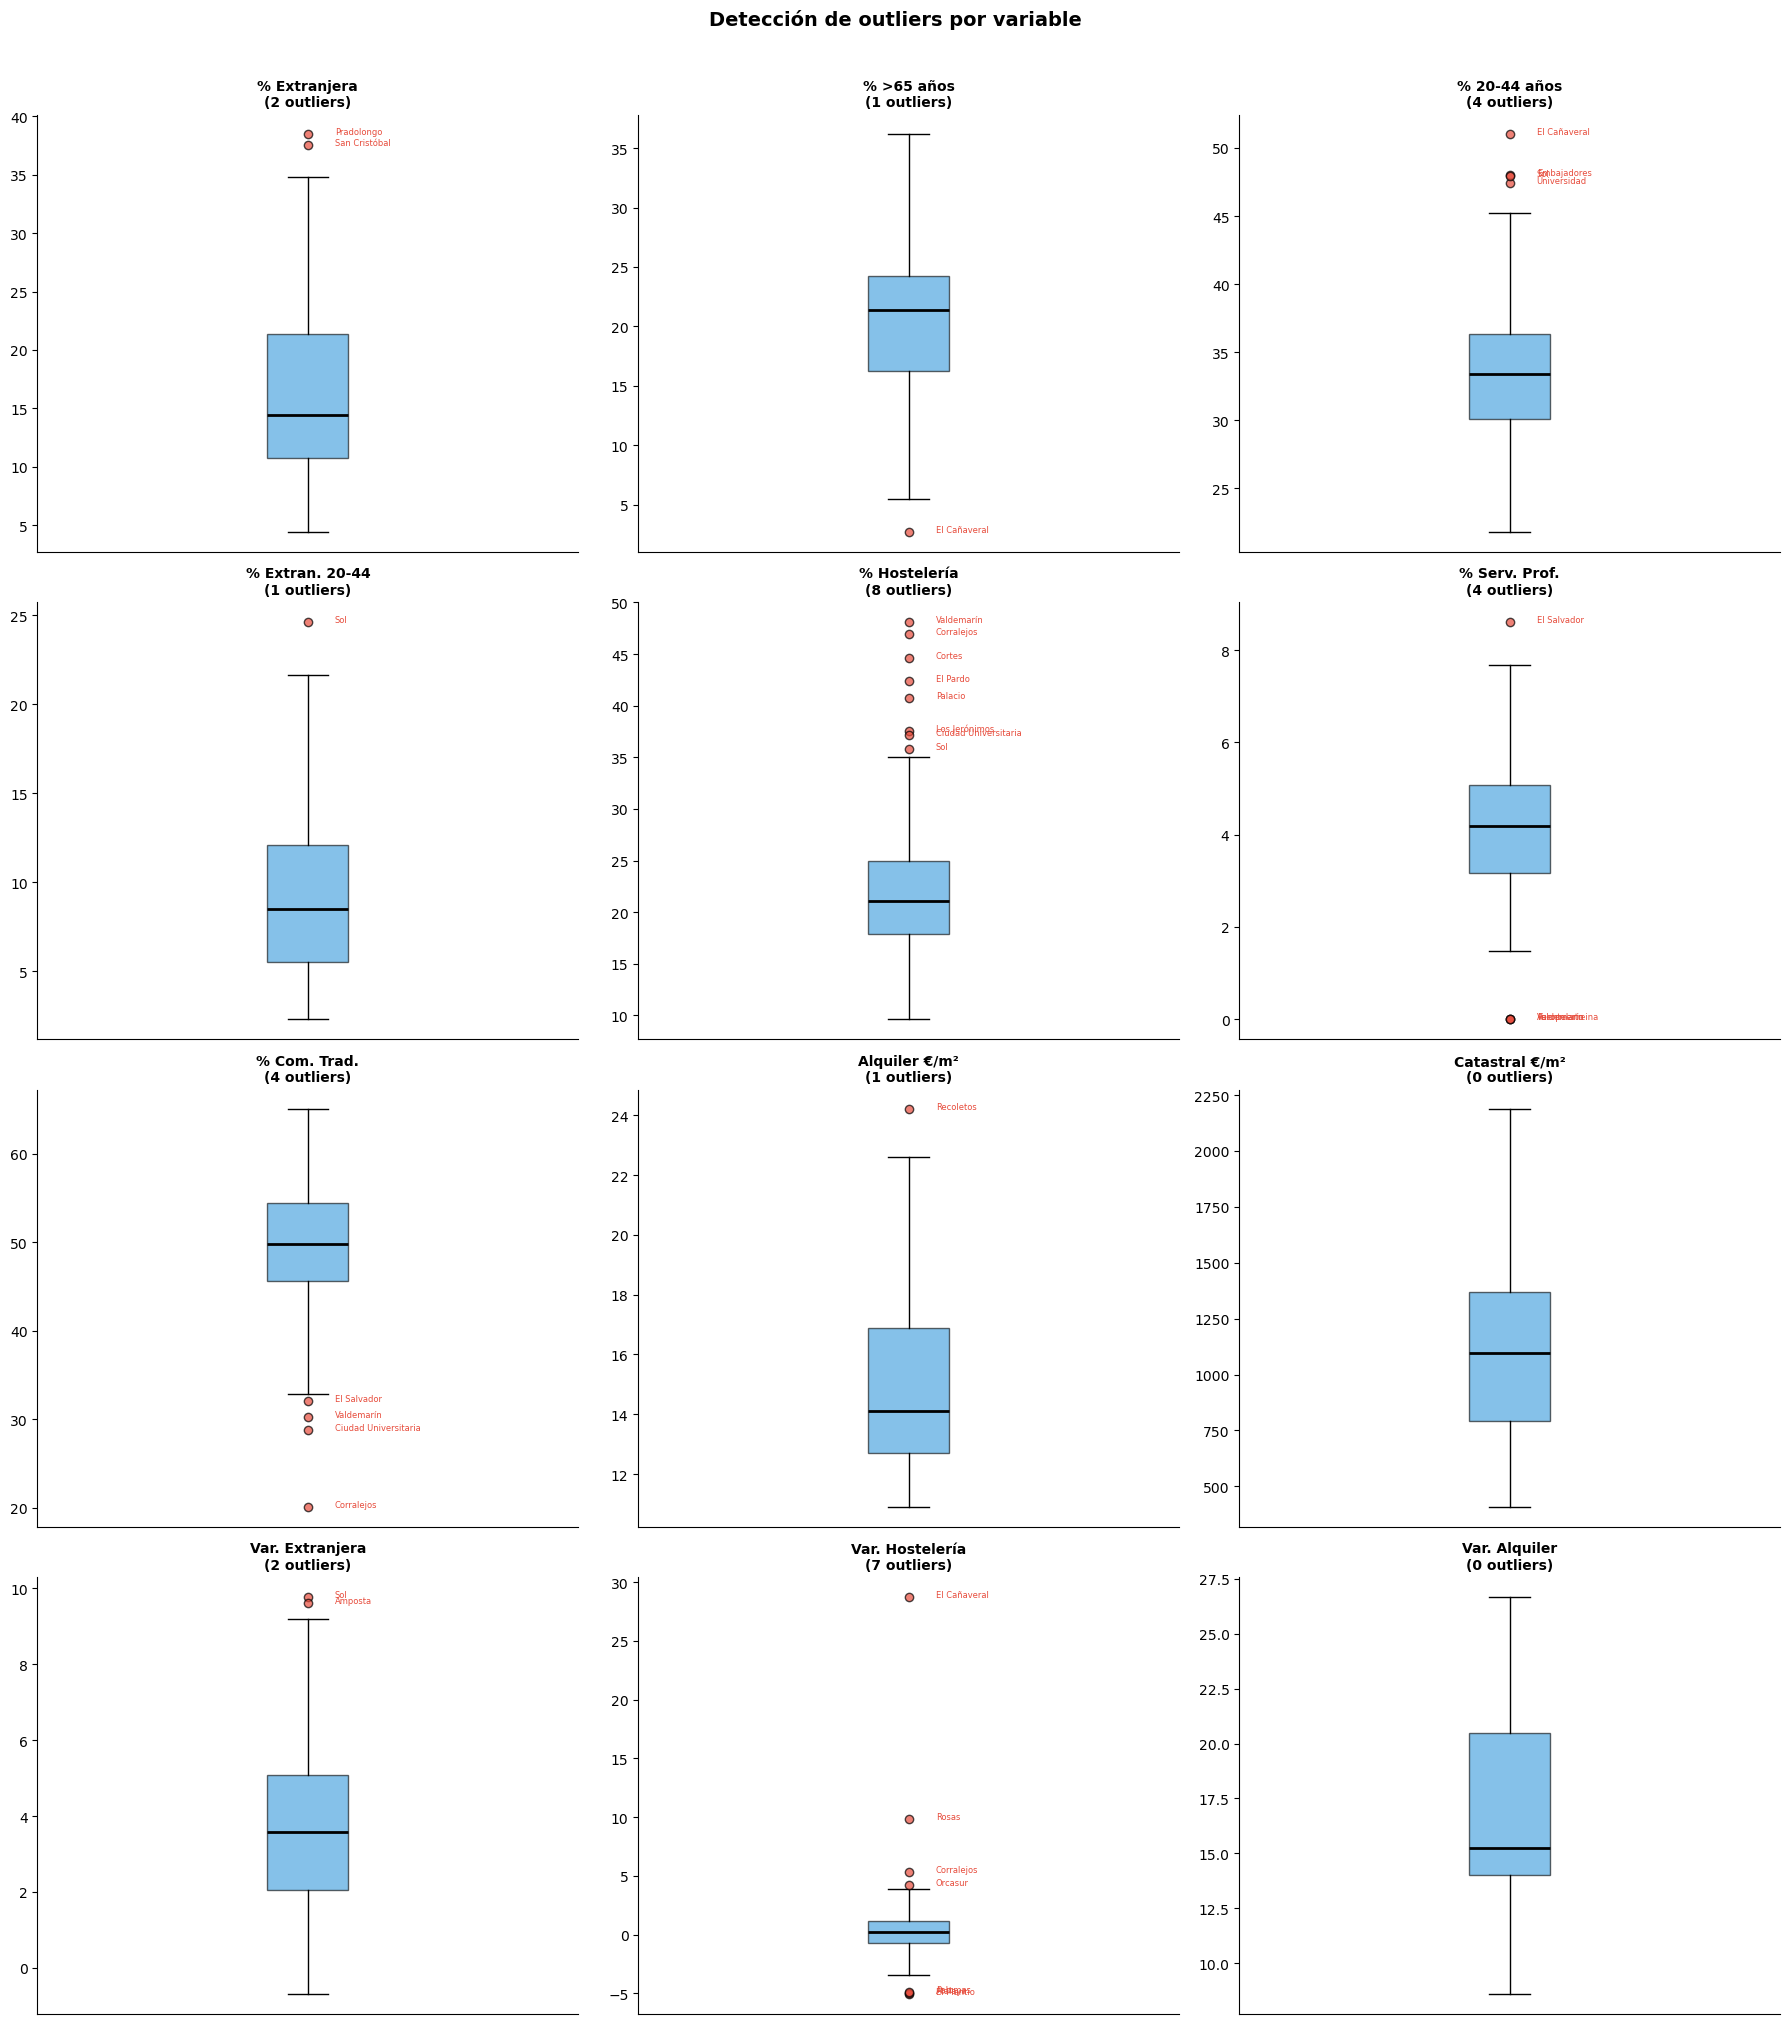

In [11]:
#Boxplots por variable

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, (var, etiqueta) in enumerate(zip(variables_plot, etiquetas)):
    ax = axes[i]
    
    datos = df[var].dropna()
    
    bp = ax.boxplot(datos, patch_artist=True, vert=True,
                    medianprops={'color': 'black', 'linewidth': 2},
                    flierprops={'marker': 'o', 'markerfacecolor': '#E74C3C','markersize': 6, 'alpha': 0.7})
    
    bp['boxes'][0].set_facecolor('#3498DB')
    bp['boxes'][0].set_alpha(0.6)
    
    #Identificación de outliers
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    limite_sup = q3 + 1.5 * iqr
    limite_inf = q1 - 1.5 * iqr
    
    outliers = df[['barrio', var]][(df[var] > limite_sup) | (df[var] < limite_inf)]
    
    for _, row in outliers.iterrows():
        nombre = row['barrio'].split('. ', 1)[1] if '. ' in row['barrio'] else row['barrio']
        ax.annotate(nombre, (1, row[var]), fontsize=6, ha='left', xytext=(1.05, row[var]), color='#E74C3C')
    
    ax.set_title(f'{etiqueta}\n({len(outliers)} outliers)', fontsize=10, fontweight='bold')
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Detección de outliers por variable', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES + 'boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()